# Hierarchical Possession-Aware Graph Pointer Network (HPGPN)
GNN Backbone: GraphSAGE， dataset: euro 2024， Maximum History Window Length: K=40 

In [ ]:
from pathlib import Path
import copy
import pandas as pd

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split

from hpgpn.datasets import GraphPassSelectionDatasetWithEventContextAndContextualizedPassHistory
from hpgpn.components.pass_selection import ContextualizedPassHistoryHierarchicalAttentionGraphSAGE


# --------------------------
# 1) 
# --------------------------
train_path = Path("../stores/datasets/euro2024/train")
test_path = Path("../stores/datasets/euro2024/test")


# --------------------------
# 2) 
# --------------------------
history_len = 40

train_full = GraphPassSelectionDatasetWithEventContextAndContextualizedPassHistory(
    path=train_path,
    history_len=history_len,
)

test_ds = GraphPassSelectionDatasetWithEventContextAndContextualizedPassHistory(
    path=test_path,
    history_len=history_len,
    context_mean=train_full.context_mean,
    context_std=train_full.context_std,
    history_cols=train_full.history_cols,
    history_mean=train_full.history_mean,
    history_std=train_full.history_std,
)

print("history mode: contextualized pass history")
print("train len:", len(train_full))
print("test len:", len(test_ds))
print("context dim:", train_full[0].event_context.shape[0])
print("history dim:", train_full.history_dim)
print("history len setting:", history_len)

event_window_lengths = []
pass_token_lengths = []

for idx in range(len(train_full)):
    sample = train_full[idx]

    event_window_lengths.append(sample.possession_history.shape[0])
    pass_token_lengths.append(int(sample.history_pass_mask.sum()))

history_summary = pd.DataFrame({
    "event_window_len": event_window_lengths,
    "contextualized_pass_token_len": pass_token_lengths,
})

display(history_summary.describe())

assert (
    history_summary["contextualized_pass_token_len"]
    <= history_summary["event_window_len"]
).all()

assert (
    history_summary["event_window_len"]
    <= history_len
).all()

print(
    "samples with non-empty event history:",
    (history_summary["event_window_len"] > 0).sum(),
)
print(
    "samples with contextualized pass tokens:",
    (history_summary["contextualized_pass_token_len"] > 0).sum(),
)
# --------------------------
# 3) 
# --------------------------
val_ratio = 0.2
n_val = int(len(train_full) * val_ratio)
n_train = len(train_full) - n_val

train_ds, val_ds = random_split(
    train_full,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(42),
)

print("train len:", len(train_ds))
print("val len:", len(val_ds))
print("test len:", len(test_ds))


# --------------------------
# 4) DataLoader
# --------------------------
def collate_graph_samples(batch):
    return batch

batch_size = 32

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_graph_samples,
)

val_loader = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_graph_samples,
)

test_loader = DataLoader(
    test_ds,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_graph_samples,
)


# --------------------------
# 5) model
# --------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

sample = train_full[0]

node_dim = sample.node_features.shape[-1]
context_dim = sample.event_context.shape[-1]
history_dim = train_full.history_dim

time_delta_col = "hist_time_delta_to_current"
time_delta_idx = train_full.history_cols.index(time_delta_col)

model = ContextualizedPassHistoryHierarchicalAttentionGraphSAGE(
    node_dim=node_dim,
    context_dim=context_dim,
    history_dim=history_dim,
    hidden_dim=64,
    time_delta_idx=time_delta_idx,
    num_heads=4,
    temporal_layers=1,
    dropout=0.1,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


# --------------------------
# 6) 
# --------------------------
def move_sample_to_device(sample, device):
    sample.node_features = sample.node_features.to(device)
    sample.edge_index = sample.edge_index.to(device)
    sample.edge_features = sample.edge_features.to(device)
    sample.candidate_mask = sample.candidate_mask.to(device)
    sample.target_index = sample.target_index.to(device)

    sample.event_context = sample.event_context.to(device)

    sample.possession_history = sample.possession_history.to(device)
    sample.history_pass_mask = sample.history_pass_mask.to(device)

    sample.has_history = sample.has_history.to(device)
    sample.stored_history_len_norm = sample.stored_history_len_norm.to(device)

    sample.has_pass_history = sample.has_pass_history.to(device)
    sample.pass_history_len_norm = sample.pass_history_len_norm.to(device)

    return sample


def run_one_epoch(model, loader, device, optimizer=None):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_correct = 0
    total_graphs = 0

    for batch in loader:
        batch_loss = 0.0
        batch_correct = 0

        for sample in batch:
            sample = move_sample_to_device(sample, device)

            if is_train:
                scores = model(sample)
                loss = F.cross_entropy(
                    scores.unsqueeze(0),
                    sample.target_index.unsqueeze(0),
                )
            else:
                with torch.no_grad():
                    scores = model(sample)
                    loss = F.cross_entropy(
                        scores.unsqueeze(0),
                        sample.target_index.unsqueeze(0),
                    )

            batch_loss += loss

            pred = torch.argmax(scores).item()
            if pred == sample.target_index.item():
                batch_correct += 1

        batch_loss = batch_loss / len(batch)

        if is_train:
            optimizer.zero_grad()
            batch_loss.backward()
            optimizer.step()

        total_loss += batch_loss.item() * len(batch)
        total_correct += batch_correct
        total_graphs += len(batch)

    return {
        "loss": total_loss / max(total_graphs, 1),
        "acc": total_correct / max(total_graphs, 1),
    }


history mode: contextualized pass history
train len: 28331
test len: 6042
context dim: 134
history dim: 42
history len setting: 40


,event_window_len,contextualized_pass_token_len
count,28331.000000,28331.000000
mean,14.738979,6.866118
std,12.439412,6.148736
min,0.000000,0.000000
25%,4.000000,2.000000
50%,11.000000,5.000000
75%,22.000000,11.000000
max,40.000000,23.000000


samples with non-empty event history: 27059
samples with contextualized pass tokens: 25285
train len: 22665
val len: 5666
test len: 6042
device: cuda


In [3]:

"""sample = ds[0]
print(sample.node_features.shape)
print(sample.edge_index.shape)
print(sample.edge_features.shape)

model = GraphReceiverSelectionModel(
    node_dim=sample.node_features.shape[1],
    edge_dim=sample.edge_features.shape[1],
    hidden_dim=64,
).to(device)

sample = move_sample_to_device(sample, device)
scores = model(sample)

print("scores.shape:", scores.shape)
print("num_candidates:", sample.candidate_mask.sum().item())"""

'sample = ds[0]\nprint(sample.node_features.shape)\nprint(sample.edge_index.shape)\nprint(sample.edge_features.shape)\n\nmodel = GraphReceiverSelectionModel(\n    node_dim=sample.node_features.shape[1],\n    edge_dim=sample.edge_features.shape[1],\n    hidden_dim=64,\n).to(device)\n\nsample = move_sample_to_device(sample, device)\nscores = model(sample)\n\nprint("scores.shape:", scores.shape)\nprint("num_candidates:", sample.candidate_mask.sum().item())'

In [4]:
max_epochs = 100
patience = 10
min_delta = 1e-4
history = []

best_val_acc = -1.0
best_epoch = -1
best_state_dict = None
epochs_no_improve = 0

for epoch in range(1, max_epochs + 1):
    train_metrics = run_one_epoch(model, train_loader, device, optimizer=optimizer)
    val_metrics = run_one_epoch(model, val_loader, device, optimizer=None)

    row = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_acc": train_metrics["acc"],
        "val_loss": val_metrics["loss"],
        "val_acc": val_metrics["acc"],
    }
    history.append(row)

    improved = row["val_acc"] > best_val_acc + min_delta

    if improved:
        best_val_acc = row["val_acc"]
        best_epoch = epoch
        best_state_dict = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    print(
        f"epoch {epoch:03d} | "
        f"train_loss={row['train_loss']:.4f} "
        f"train_acc={row['train_acc']:.4f} | "
        f"val_loss={row['val_loss']:.4f} "
        f"val_acc={row['val_acc']:.4f} | "
        f"no_improve={epochs_no_improve}/{patience}"
    )

    if epochs_no_improve >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch}.")
        break

print("\nBest validation result:")
print(f"best_epoch = {best_epoch}")
print(f"best_val_acc = {best_val_acc:.4f}")

epoch 001 | train_loss=1.3320 train_acc=0.4885 | val_loss=1.2737 val_acc=0.5199 | no_improve=0/10


epoch 002 | train_loss=1.2658 train_acc=0.5152 | val_loss=1.2461 val_acc=0.5309 | no_improve=0/10


epoch 003 | train_loss=1.2326 train_acc=0.5307 | val_loss=1.2152 val_acc=0.5409 | no_improve=0/10


epoch 004 | train_loss=1.2110 train_acc=0.5405 | val_loss=1.2070 val_acc=0.5434 | no_improve=0/10


epoch 005 | train_loss=1.1866 train_acc=0.5497 | val_loss=1.1675 val_acc=0.5651 | no_improve=0/10


...

epoch 019 | train_loss=1.0025 train_acc=0.6236 | val_loss=1.0858 val_acc=0.6006 | no_improve=6/10


epoch 020 | train_loss=0.9972 train_acc=0.6273 | val_loss=1.0979 val_acc=0.5950 | no_improve=7/10


epoch 021 | train_loss=0.9897 train_acc=0.6295 | val_loss=1.0843 val_acc=0.6002 | no_improve=8/10


epoch 022 | train_loss=0.9851 train_acc=0.6320 | val_loss=1.1063 val_acc=0.5860 | no_improve=9/10


epoch 023 | train_loss=0.9763 train_acc=0.6345 | val_loss=1.1102 val_acc=0.5879 | no_improve=10/10

Early stopping triggered at epoch 23.

Best validation result:
best_epoch = 13
best_val_acc = 0.6020


In [ ]:

model.load_state_dict(best_state_dict)

test_metrics = run_one_epoch(model, test_loader, device, optimizer=None)

print("\nFinal test result (aligned with original project):")
print(f"test_loss = {test_metrics['loss']:.4f}")
print(f"test_acc  = {test_metrics['acc']:.4f}")


Final test result (aligned with original project):
test_loss = 1.0879
test_acc  = 0.6001


,epoch,train_loss,train_acc,val_loss,val_acc
0,1,1.332010,0.488507,1.273707,0.519944
1,2,1.265800,0.515244,1.246115,0.530886
2,3,1.232635,0.530730,1.215216,0.540946
3,4,1.210971,0.540525,1.206963,0.543417
4,5,1.186594,0.549746,1.167455,0.565125
5,6,1.151714,0.564792,1.135623,0.574126
6,7,1.124065,0.578734,1.152594,0.571655
7,8,1.103502,0.585440,1.129971,0.582068
8,9,1.086423,0.592279,1.107456,0.587010
9,10,1.074635,0.600221,1.104080,0.584716


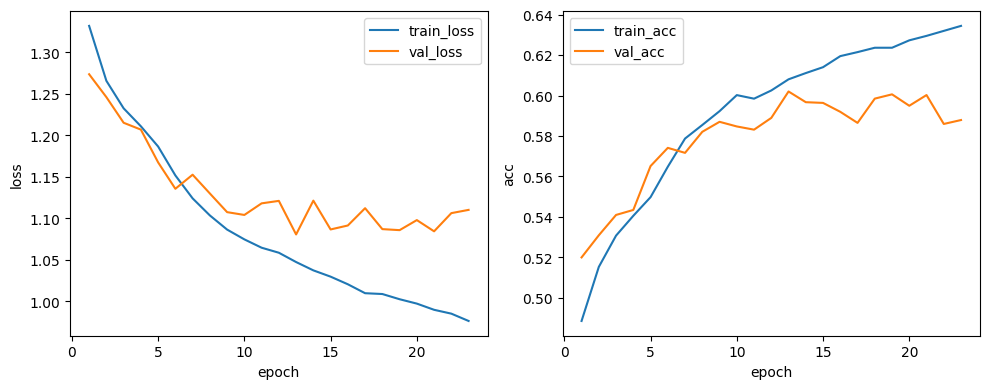

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

hist = pd.DataFrame(history)
display(hist)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(hist["epoch"], hist["train_loss"], label="train_loss")
plt.plot(hist["epoch"], hist["val_loss"], label="val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist["epoch"], hist["train_acc"], label="train_acc")
plt.plot(hist["epoch"], hist["val_acc"], label="val_acc")
plt.xlabel("epoch")
plt.ylabel("acc")
plt.legend()

plt.tight_layout()
plt.show()


In [7]:
from pathlib import Path
import torch

# --------------------------
# Save best model checkpoint
# --------------------------
model_dir = Path("../stores/model")
model_dir.mkdir(parents=True, exist_ok=True)

run_name = f"gnn75_ctx_pass_hist_euro2024_h{history_len}"

model_filename = (
    f"{run_name}"
    f"_best_ep{best_epoch:03d}"
    f"_val{best_val_acc:.4f}"
    f"_test{test_metrics['acc']:.4f}"
    ".pt"
)

model_path = model_dir / model_filename

checkpoint = {
    "run_name": run_name,
    "full_notebook_name": f"pass_selection_gnn75_contextualized_pass_history_hierarchical_attention_graphsage_euro2024_history{history_len}",
    "model_class": model.__class__.__name__,
    "best_epoch": best_epoch,
    "best_val_acc": best_val_acc,
    "test_loss": test_metrics["loss"],
    "test_acc": test_metrics["acc"],
    "model_state_dict": best_state_dict,
    "optimizer_state_dict": optimizer.state_dict(),
    "hidden_dim": 64,
    "node_dim": node_dim,
}

if hasattr(train_full, "context_mean"):
    checkpoint["context_mean"] = train_full.context_mean
    checkpoint["context_std"] = train_full.context_std

if "context_dim" in globals():
    checkpoint["context_dim"] = context_dim

torch.save(checkpoint, model_path)

print("Saved best model checkpoint:")
print(model_path)
print("model filename:")
print(model_filename)

Saved best model checkpoint:
../stores/model/gnn75_ctx_pass_hist_euro2024_h40_best_ep013_val0.6020_test0.6001.pt
model filename:
gnn75_ctx_pass_hist_euro2024_h40_best_ep013_val0.6020_test0.6001.pt
